# Choosing the churn window

There is no churn column in the data, so we have to define churn ourselves: a customer churned when they stopped ordering for longer than some window. But how long is "too long"? 30 days would be normal for groceries, way too strict for fashion.

The honest way to pick the window is to look at how often existing customers actually reorder. That is what this notebook does.

In [6]:
import os
import sys

if os.path.exists("work/src"):
    os.chdir("work")
elif os.path.exists("../src"):
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from src.common.spark import get_spark
from src.ingestion.load_thelook import load_table, load_us_users
from src.processing.churn_label import justify_window, label_churn, cutoff_date
import pyspark.sql.functions as F

spark = get_spark("churn-window-analysis")
spark.sparkContext.setLogLevel("ERROR")
orders = load_table(spark, "orders")

## Gaps between consecutive orders

For every customer with more than one order: how many days sit between order N and order N+1?

In [7]:
justify_window(orders).show()

+---+---+---+---+---+---+
|p25|p50|p75|p80|p90|p95|
+---+---+---+---+---+---+
| 48|155|365|433|640|835|
+---+---+---+---+---+---+



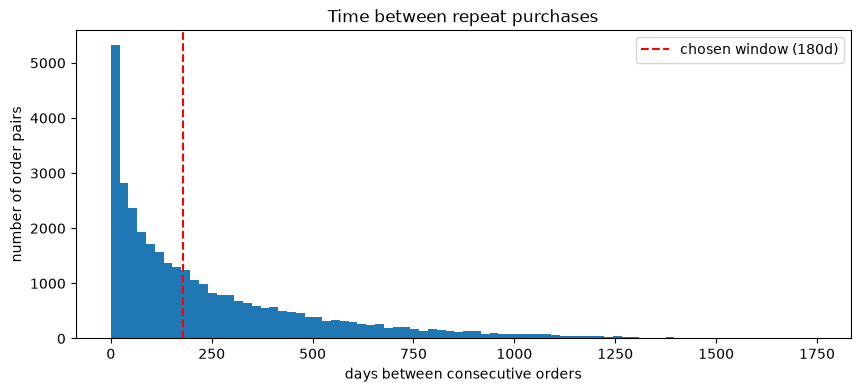

In [8]:
# same thing but as a histogram
from pyspark.sql.window import Window
from src.processing.churn_label import valid_orders
import matplotlib.pyplot as plt

w = Window.partitionBy("user_id").orderBy("created_at")
gaps = (
    valid_orders(orders)
    .withColumn("prev", F.lag("created_at").over(w))
    .filter(F.col("prev").isNotNull())
    .withColumn("gap_days", F.datediff("created_at", "prev"))
    .select("gap_days")
    .toPandas()
)

plt.figure(figsize=(10, 4))
plt.hist(gaps["gap_days"], bins=80)
plt.axvline(180, color="red", linestyle="--", label="chosen window (180d)")
plt.xlabel("days between consecutive orders")
plt.ylabel("number of order pairs")
plt.title("Time between repeat purchases")
plt.legend()
plt.show()

## What the label looks like at different windows

The median gap is around 155 days, customers here reorder slowly. That already rules out the typical 90 day window you see in a lot of churn tutorials.

Note on the definition: the label uses a temporal cutoff. We place the cutoff N days before the end of the data, and churned means the customer did not order again after the cutoff. So this measures "will they come back within the next N days", not "have they been quiet for N days". The features for the model are built from data before the cutoff only, otherwise recency features would leak the answer.

In [9]:
for days in (90, 180, 365):
    cutoff = cutoff_date(orders, days)
    dist = label_churn(orders, cutoff).groupBy("churned").count().collect()
    d = {r["churned"]: r["count"] for r in dist}
    total = d.get(0, 0) + d.get(1, 0)
    print(f"{days:>3} days: {d.get(1,0):,} churned ({d.get(1,0)/total:.0%}), {d.get(0,0):,} retained")

 90 days: 53,632 churned (90%), 5,690 retained
180 days: 43,458 churned (85%), 7,830 retained
365 days: 29,201 churned (76%), 9,047 retained


## Decision

I opted for 180 days, because:

1. It is longer than the median reorder gap (155d), so a customer has to be quiet for longer than a typical cycle before we call them gone.
2. Six months without buying is a defensible business definition for fashion e-commerce, where seasons drive repeat purchases.
3. Widening the window barely improves the class balance (even at 365 days roughly three quarters churn), it just costs a year of recent behavior for the features. Most shoppers here buy once and never return.

So the label ends up around 85/15 no matter which reasonable window we pick. That is a property of the business, not of the definition, and it gets handled in the modeling step with class weights and metrics that work under imbalance.

The value lives in `CHURN_WINDOW_DAYS` in `src/processing/churn_label.py`.

In [10]:
spark.stop()